# Fraud & Return Risk: Predictive ML Classification

## Overview

The last two notebooks in this portfolio approached order risk the same general way: a person decides what the risk signals are, then writes that decision down as fixed logic. In the SQL notebook, that logic was a `CASE WHEN` governance rule engine -- if the traffic source is Paid Ads and the IP is flagged, block the order; if it's a Return Risk order over a certain value, send it to logistics review; and so on. In the LLM notebook, the logic was still fixed, just translated into SQL by a model instead of typed by hand.

This notebook does something different: instead of writing the rules myself, I'm handing the model a set of features and the actual outcomes (`is_fraud`, `is_returned`), and letting it work out on its own which combinations of signals actually predict risk. The hope is that a model can pick up on interactions and thresholds that are genuinely hard to spot by eye -- the kind of pattern where, say, high shipping distance only matters when it's combined with a new account and a mismatched address, not on its own.

I'm predicting two separate outcomes here, and I want to be upfront about why both, rather than picking one and calling it a day. Fraud and returns are not the same kind of problem:

- **Fraud** is rare (well under 4% of all orders) and adversarial -- someone is actively trying not to get caught, so the signal is often subtle and the cost of missing a case is high.
- **Returns** are far more common (about 9% of orders) and mostly behavioral, not adversarial -- a customer ordering three sizes of the same shoe to try on at home isn't hiding anything, they're just shopping in a way that happens to generate a return.

Building both from the same pipeline (same features, same train/test setup, same evaluation code) rather than treating them as two unrelated one-off projects is deliberate. It's a stronger demonstration of actually understanding the problem than two disconnected scripts would be, and it also means whatever I learn about which features matter for fraud, I get to check for free against a second, differently-shaped target.

The other new piece here, compared to the SQL notebook: the governance rule engine gets scored the same way the ML models do. Up to now, "the rules seem to work reasonably well" was really just an impression from looking at a handful of example rows. Here, I'm running that exact rule logic against the whole dataset and computing precision and recall for it, so there's an actual number on the table before I claim a learned model is any better.

## What I'm trying to get out of this notebook

1. Rebuild the SQL governance rule engine in pandas and score it like a classifier, so there's a real baseline number rather than a vibe.
2. Build a set of engineered features from the raw columns, and set up a single reusable pipeline for training and evaluating a model.
3. Train a fraud model and a returns model using that same pipeline, comparing a simple baseline against a stronger model for each.
4. Judge everything using metrics that actually mean something when the positive class is rare. Accuracy is a trap here -- a model that predicts "not fraud" on every single row would be right 96% of the time and would be completely useless, since it would never catch a single fraudulent order. Precision, recall, and precision-recall AUC are what actually matter for this kind of problem.
5. Put the rule engine and the ML models side by side and look at where they agree, where they disagree, and what the disagreements are actually telling us about the limits of hand-written rules.

## Data

Same 12,000-row synthetic e-commerce dataset used everywhere else in this portfolio (`synthetic_ecommerce_order_risk_dataset.csv`) -- 23 columns covering order details, behavioral and fraud-adjacent signals, and the three outcome fields (`is_fraud`, `is_returned`, `risk_label`). No SQLite database this time. Everything from here on is a pandas DataFrame going into scikit-learn, and there's no SQL being executed anywhere in this notebook, so loading straight from the CSV is the honest choice rather than routing through a database for no reason.

Related repos, if you want the fuller picture this notebook is one piece of:
- SQL auditing, the governance rule engine, and the Power BI / Tableau / Looker Studio dashboards: [multi-platform-ecommerce-governance-analytics](https://github.com/bernard-omondi/multi-platform-ecommerce-governance-analytics)
- The LLM text-to-SQL co-pilot: [ecommerce-risk-sql-llm-copilot](https://github.com/bernard-omondi/ecommerce-risk-sql-llm-copilot)

## Section 1: Setup

Starting with the basics: load the data, and actually look at it before doing anything else to it.

One thing about how I'm structuring imports in this notebook: I'm not importing every library I'll eventually need right at the top. `scikit-learn` doesn't show up until the section where it's actually used. Part of the reason is honestly just clarity -- if you're reading this notebook section by section, it's a lot easier to tell what a given section depends on when the imports are sitting right above the code that uses them, instead of buried in one big block at the very top that you'd have to scroll back to remember. The tradeoff is that a couple of very standard libraries (`pandas`, `numpy`, the plotting libraries) do get imported once here up front, since basically every section touches those.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('synthetic_ecommerce_order_risk_dataset.csv')
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
df.head()

Loaded 12,000 rows and 23 columns


,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,03/01/2024,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,26/11/2025,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,0.03,528.2,4,0,0,0,0,4.8,0,0,Normal
2,ORD-2023-001721,07/11/2023,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,55.49,1,0.05,175.1,5,0,0,0,0,3.3,0,0,Normal
3,ORD-2024-009121,28/05/2024,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,112.54,5,0.22,271.4,3,0,0,0,0,4.2,1,0,Return Risk
4,ORD-2025-000361,31/01/2025,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,55.32,8,0.25,285.3,3,0,1,0,0,5.0,0,0,Normal


Twelve thousand rows, twenty-three columns, matching what every other notebook in this portfolio has been working from -- good, that confirms I'm looking at the same source of truth as the SQL and LLM notebooks, not some different export.

Let's check the column types and confirm nothing unexpected slipped in on load (dates coming through as text instead of getting auto-parsed, numbers coming through as strings because of a stray comma, that sort of thing).

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   12000 non-null  str    
 1   order_date                 12000 non-null  str    
 2   country                    12000 non-null  str    
 3   device_type                12000 non-null  str    
 4   traffic_source             12000 non-null  str    
 5   payment_method             12000 non-null  str    
 6   product_category           12000 non-null  str    
 7   customer_age_days          12000 non-null  int64  
 8   previous_orders            12000 non-null  int64  
 9   avg_order_value_eur        12000 non-null  float64
 10  order_value_eur            12000 non-null  float64
 11  quantity                   12000 non-null  int64  
 12  discount_rate              12000 non-null  float64
 13  shipping_distance_km       12000 non-null  float64
 14  d

That all looks right -- the binary flag columns (`is_fraud`, `high_risk_ip`, `late_delivery_risk`, and so on) came through as integers rather than something odd like booleans-as-strings, and the money/distance columns are floats. `order_date` is text rather than a real date, which is expected and fine here -- nothing in this notebook does date arithmetic on it the way the SQL notebook's window functions did, so there's no need to fight with the DD/MM/YYYY format this time.

Before building anything else, I want two things confirmed: that there's genuinely no missing data (rather than just assuming so because the SQL audits didn't flag any), and the exact class balance for both targets. That second one matters more than it might sound like -- the fraud rate specifically is the number that's going to shape almost every modeling decision later in this notebook, from how I split the data to which metrics are even meaningful to look at.

In [3]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "None -- clean dataset.")

print()
print("is_fraud value counts:")
print(df['is_fraud'].value_counts())
print(f"Fraud rate: {df['is_fraud'].mean():.2%}")

print()
print("is_returned value counts:")
print(df['is_returned'].value_counts())
print(f"Return rate: {df['is_returned'].mean():.2%}")

Missing values per column:
None -- clean dataset.

is_fraud value counts:
is_fraud
0    11553
1      447
Name: count, dtype: int64
Fraud rate: 3.72%

is_returned value counts:
is_returned
0    10888
1     1112
Name: count, dtype: int64
Return rate: 9.27%


No missing values anywhere, so no imputation decisions to make or justify later -- one less thing to worry about.

The two rates are worth sitting with for a second before moving on. A 3.72% fraud rate means that out of every 100 orders, roughly 96 are legitimate and 4 are fraudulent -- and it means a model needs to do real work to beat the trivial "just guess not-fraud every time" strategy, which would already be right 96.28% of the time while being useless in practice. That's exactly why accuracy is the wrong metric to reach for later on, and why the evaluation section is going to lean on precision, recall, and precision-recall AUC instead.

The 9.27% return rate tells a similar story but at roughly two and a half times the frequency -- returns are still a minority class, but a noticeably less extreme one than fraud. That difference alone is a hint that the returns model and the fraud model are probably going to behave differently once we get to training and evaluation, even before any features are built.

## Section 2: EDA -- Target Distributions

Section 1 gave us the two headline numbers -- 3.72% fraud, 9.27% returned. Before touching features, I want to look at these two targets a bit more closely: what the imbalance actually looks like side by side, and whether fraud and returns are related to each other at all. That second question matters for a very practical reason -- if fraud and returns turned out to be highly correlated, treating them as two independent modeling problems would be a mistake, and I'd want to know that now rather than after building two separate pipelines.

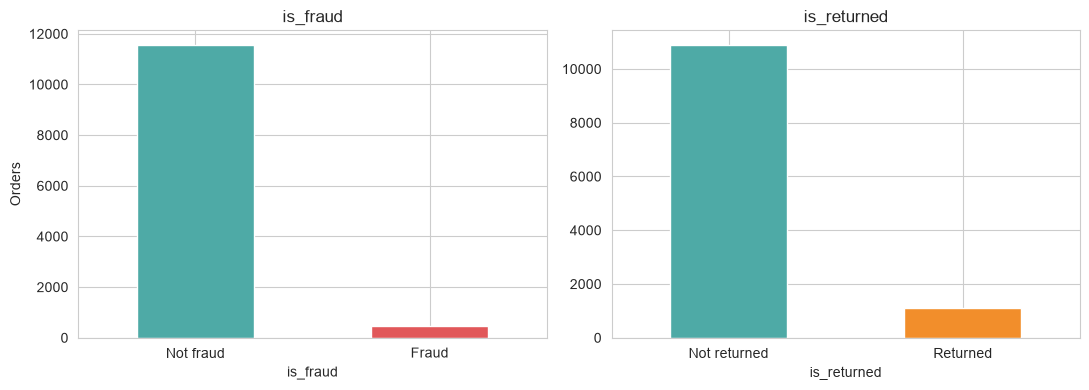

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df['is_fraud'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#4EAAA6', '#E15759']
)
axes[0].set_title('is_fraud')
axes[0].set_xticklabels(['Not fraud', 'Fraud'], rotation=0)
axes[0].set_ylabel('Orders')

df['is_returned'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#4EAAA6', '#F28E2B']
)
axes[1].set_title('is_returned')
axes[1].set_xticklabels(['Not returned', 'Returned'], rotation=0)

plt.tight_layout()
plt.show()

The fraud bar chart barely shows a second bar at all -- that's the imbalance made visible rather than just stated as a percentage. Returns are more visible but still clearly a minority class.

Now the question I actually care about: does fraud and returns overlap? A fraudster who gets caught presumably isn't also requesting a refund on the same order, but I don't want to assume that -- I'd rather check it.

In [5]:
pd.crosstab(df['is_fraud'], df['is_returned'], margins=True, margins_name='Total')

is_returned,0,1,Total
is_fraud,,,
0,10482,1071,11553
1,406,41,447
Total,10888,1112,12000


In [6]:
return_rate_fraud = df.loc[df['is_fraud'] == 1, 'is_returned'].mean()
return_rate_not_fraud = df.loc[df['is_fraud'] == 0, 'is_returned'].mean()
fraud_rate_returned = df.loc[df['is_returned'] == 1, 'is_fraud'].mean()
fraud_rate_not_returned = df.loc[df['is_returned'] == 0, 'is_fraud'].mean()

print(f"Return rate among fraud orders:      {return_rate_fraud:.2%}")
print(f"Return rate among non-fraud orders:  {return_rate_not_fraud:.2%}")
print()
print(f"Fraud rate among returned orders:     {fraud_rate_returned:.2%}")
print(f"Fraud rate among non-returned orders: {fraud_rate_not_returned:.2%}")

Return rate among fraud orders:      9.17%
Return rate among non-fraud orders:  9.27%

Fraud rate among returned orders:     3.69%
Fraud rate among non-returned orders: 3.73%


Those four numbers are almost identical in each pair -- roughly 9.2% either way, and roughly 3.7% either way. In other words, knowing whether an order is fraudulent tells you basically nothing about whether it'll be returned, and vice versa. In this dataset, the two are essentially independent.

That's a genuinely useful result, not just a box to check. It confirms treating fraud and returns as two separate modeling problems is the right call, rather than something to compromise on -- there's no shared signal being split awkwardly between two models. It also means I shouldn't expect much benefit from using one target as a feature for the other later on.

There's a third column in the dataset that's worth bringing into this, since it's a simplified, single-column version of exactly what I've been checking: `risk_label`, which was used throughout the SQL notebook.

In [7]:
df.groupby('risk_label')[['is_fraud', 'is_returned']].agg(['sum', 'mean'])

is_fraud      is_returned          
                 sum mean         sum      mean
risk_label                                     
Fraud Risk       447  1.0          41  0.091723
Normal             0  0.0           0  0.000000
Return Risk        0  0.0        1071  1.000000

This is worth reading carefully, because it explains something the crosstab above hinted at. Every single `Fraud Risk` row has `is_fraud = 1` -- that part's expected. But notice the `is_returned` mean for that same group: 9.17%, not zero. That means 41 orders are *both* fraudulent *and* returned, and `risk_label` quietly assigns all 41 of them to `Fraud Risk` only. The return signal doesn't disappear from the data, but it does disappear from that single label -- `risk_label` looks like it's built with fraud taking priority over returns whenever an order happens to be both.

That's a real limitation of collapsing two independent risks into one three-way category, and it's the concrete reason I'm modeling `is_fraud` and `is_returned` as two separate binary targets in this notebook rather than trying to predict `risk_label` directly as a single three-class problem. Predicting `risk_label` would mean inheriting that same priority-collapsing behavior -- and quietly losing the ability to ever flag those 41 orders as return risks at all.

## Section 3: EDA -- Feature Relationships

Now the wider question: out of all the numeric and binary columns in this dataset, which ones actually move with `is_fraud`, and which move with `is_returned`? This is exactly the situation I flagged earlier as the right use case for a heatmap -- fifteen variables, all pairwise relationships at once, scanning for the few that stand out rather than reading through a table of fifteen rows by fifteen columns of numbers one at a time.

I'm restricting this to numeric and binary columns only (categorical columns like `country`, `device_type`, and `payment_method` don't have a meaningful correlation coefficient in raw form -- they'd need encoding first, which is coming in the feature engineering section).

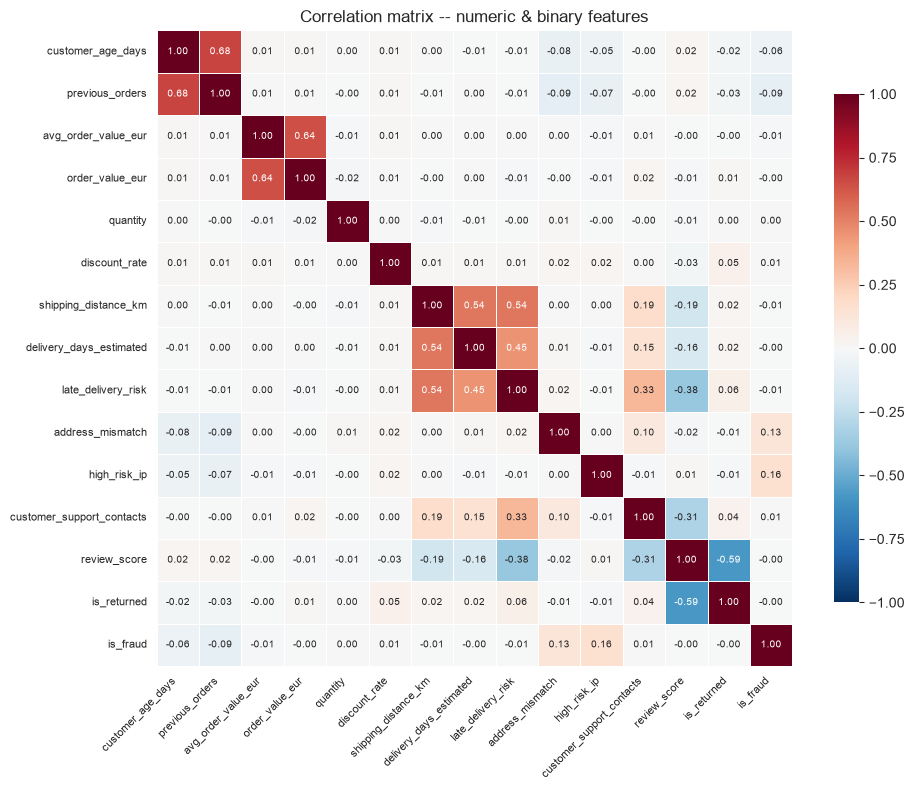

In [8]:
numeric_cols = ['customer_age_days', 'previous_orders', 'avg_order_value_eur', 'order_value_eur',
                'quantity', 'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
                'late_delivery_risk', 'address_mismatch', 'high_risk_ip', 'customer_support_contacts',
                'review_score', 'is_returned', 'is_fraud']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 7})
plt.title('Correlation matrix -- numeric & binary features', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Two things jump out of this heatmap immediately, in the bottom two rows/columns (`is_returned` and `is_fraud`), and they're telling very different stories.

**`review_score` is strongly negative with `is_returned` (-0.59) -- by a wide margin the strongest relationship anywhere in this entire matrix.** Nothing else in the dataset comes close to that number, fraud-related or otherwise. That's worth pinning down in plain terms rather than just reading the coefficient.

In [9]:
df.groupby('is_returned')['review_score'].mean().round(2)

is_returned
0    4.51
1    3.41
Name: review_score, dtype: float64

Kept orders average a 4.51 review. Returned orders average 3.41 -- over a full point lower on what's presumably a 5-point scale. That's a strong, intuitive signal: `review_score` is going to matter a lot for the returns model, likely more than anything else in the dataset.

**Fraud tells a different story.** Nothing correlates anywhere near as strongly with `is_fraud` -- the two strongest are `high_risk_ip` (0.16) and `address_mismatch` (0.13), and both are modest on their own. Still worth looking at directly, since they're also exactly the two signals the SQL notebook's governance rule engine leaned on for blocking decisions.

In [10]:
print("high_risk_ip rate by is_fraud:")
print(df.groupby('is_fraud')['high_risk_ip'].mean().round(3))
print()
print("address_mismatch rate by is_fraud:")
print(df.groupby('is_fraud')['address_mismatch'].mean().round(3))

high_risk_ip rate by is_fraud:
is_fraud
0    0.038
1    0.215
Name: high_risk_ip, dtype: float64

address_mismatch rate by is_fraud:
is_fraud
0    0.043
1    0.190
Name: address_mismatch, dtype: float64


Fraudulent orders carry a flagged IP about 21% of the time, versus under 4% for legitimate orders -- roughly a 5-6x jump. Address mismatches show a similar pattern, about 19% versus 4%. Those numbers are exactly why the hand-written rule engine in the SQL notebook made sense as a first pass -- these two signals genuinely do separate fraud from non-fraud, and someone building that rule engine by hand clearly noticed the same thing I'm seeing here in the correlation matrix.

But notice the ceiling: even the *strongest* individual fraud signal only reaches a correlation of 0.16. Compare that to review_score's -0.59 for returns. Fraud in this dataset isn't hiding behind one dominant variable the way returns are -- it's spread thin across several weak, partial signals, none of which is decisive on its own. That's precisely the situation where a model that can combine multiple weak signals into a joint decision has real room to outperform a rule engine that can only check a couple of conditions at a time. It's also a fair warning going into the modeling section: fraud is going to be the harder of the two targets to predict well, and I shouldn't expect a fraud model to reach the kind of clean separation the returns model likely will, given how dominant `review_score` already looks here before any feature engineering has even happened.

## Section 4: Baseline -- Scoring the Governance Rule Engine

Before training anything, I want an actual number to beat. The SQL notebook built a four-tier governance rule engine -- PASS, MFA_CHALLENGE, LOGISTICS_AUDIT, IMMEDIATE_BLOCK -- and reported that IMMEDIATE_BLOCK caught fraud with what looked like very high accuracy. That was true, but it was never actually scored like a classifier: no precision, no recall, just a description of the logic and a row count. I want to rebuild that exact logic here in pandas and score it properly, so the comparison to the ML models later in this notebook is against a real number, not an impression.

Here's the rule engine, translated from the original SQL `CASE WHEN` into pandas:

In [11]:
conditions = [
    df['risk_label'] == 'Fraud Risk',
    (df['traffic_source'] == 'Paid Ads') & (df['high_risk_ip'] == 1),
    (df['traffic_source'] == 'Paid Ads') & (df['device_type'] == 'Mobile'),
    (df['traffic_source'] == 'Paid Ads') & (df['device_type'] == 'Desktop'),
    df['high_risk_ip'] == 1,
    (df['risk_label'] == 'Return Risk') & (df['order_value_eur'] > 60),
]
choices = ['IMMEDIATE_BLOCK', 'IMMEDIATE_BLOCK', 'MFA_CHALLENGE',
           'MFA_CHALLENGE', 'MFA_CHALLENGE', 'LOGISTICS_AUDIT']

df['operational_action'] = np.select(conditions, choices, default='PASS')
df['operational_action'].value_counts()

operational_action
PASS               8658
MFA_CHALLENGE      2403
IMMEDIATE_BLOCK     627
LOGISTICS_AUDIT     312
Name: count, dtype: int64

8,658 / 2,403 / 627 / 312 -- that's an exact match to the split reported in the SQL notebook, so the translation from SQL to pandas is faithful. Good, now I can trust the numbers that come out of scoring it.

`IMMEDIATE_BLOCK` is the layer that's actually meant to represent "we think this is fraud," so that's what I'll treat as the rule engine's fraud prediction. Similarly, `LOGISTICS_AUDIT` is the closest thing to a "we think this gets returned" prediction. Let's score both against the real outcomes.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

pred_fraud = (df['operational_action'] == 'IMMEDIATE_BLOCK').astype(int)
pred_returned = (df['operational_action'] == 'LOGISTICS_AUDIT').astype(int)

print("IMMEDIATE_BLOCK vs is_fraud")
print(f"  Precision: {precision_score(df['is_fraud'], pred_fraud):.3f}")
print(f"  Recall:    {recall_score(df['is_fraud'], pred_fraud):.3f}")
print(f"  F1:        {f1_score(df['is_fraud'], pred_fraud):.3f}")
print()
print("LOGISTICS_AUDIT vs is_returned")
print(f"  Precision: {precision_score(df['is_returned'], pred_returned):.3f}")
print(f"  Recall:    {recall_score(df['is_returned'], pred_returned):.3f}")
print(f"  F1:        {f1_score(df['is_returned'], pred_returned):.3f}")

IMMEDIATE_BLOCK vs is_fraud
  Precision: 0.713
  Recall:    1.000
  F1:        0.832

LOGISTICS_AUDIT vs is_returned
  Precision: 1.000
  Recall:    0.281
  F1:        0.438


Perfect recall on fraud. Perfect precision on returns. At first glance that looks like the rule engine is already doing a great job -- but a recall of exactly 1.000 should make anyone pause rather than celebrate. Catching *every single case* with a handful of `CASE WHEN` conditions isn't something rule-based systems do by accident. I want to understand why before taking these numbers at face value.

Go back to Section 2: I already established that `risk_label` isn't an independently-derived signal. `Fraud Risk` maps to `is_fraud = 1` with zero exceptions, and `Return Risk` maps to `is_returned = 1` (and `is_fraud = 0`) with zero exceptions. The rule engine's very first condition is `risk_label == 'Fraud Risk'` -- which means Layer 1 isn't *predicting* fraud at all. It's directly checking a column that already encodes the answer. The recall of 1.000 isn't a finding about the rule engine's skill; it's close to a mathematical certainty given how `risk_label` was constructed.

That's not a criticism of the SQL notebook -- using `risk_label` that way is entirely reasonable if you think of it as an existing fraud score computed by some other system (a card network's fraud model, a third-party risk API) that the rule engine is layering business logic on top of. That's a completely normal pattern in real fraud systems. But it does mean these numbers are the wrong baseline for what this notebook is trying to do. An ML model built from raw order features has no equivalent shortcut -- it has to earn its recall from scratch. Comparing it against a rule that already knows the answer wouldn't be a fair fight.

So I want to isolate the part of the rule engine that *doesn't* cheat -- the part built only from features that would genuinely be available before anyone already knows whether the order turned out to be fraud or a return.

In [13]:
# The only fraud-blocking condition that doesn't reference risk_label directly:
# Paid Ads traffic combined with a flagged IP.
honest_fraud_rule = ((df['traffic_source'] == 'Paid Ads') & (df['high_risk_ip'] == 1)).astype(int)

print("Ex-ante-only rule (Paid Ads + high_risk_ip) vs is_fraud")
print(f"  Precision: {precision_score(df['is_fraud'], honest_fraud_rule):.3f}")
print(f"  Recall:    {recall_score(df['is_fraud'], honest_fraud_rule):.3f}")
print(f"  F1:        {f1_score(df['is_fraud'], honest_fraud_rule):.3f}")

Ex-ante-only rule (Paid Ads + high_risk_ip) vs is_fraud
  Precision: 0.163
  Recall:    0.078
  F1:        0.106


That's the real number. Once the `risk_label` shortcut is removed, the rule engine's genuine, from-scratch fraud detection catches under 8% of actual fraud cases, and only 1 in 6 of its alerts are correct. That's a completely different picture from the F1 of 0.83 the full rule engine appeared to get a moment ago.

I want to be direct about what this means for the returns side too: unlike fraud, the `LOGISTICS_AUDIT` trigger has *no* non-circular component at all -- both of its conditions (`risk_label == 'Return Risk'` and the value threshold) depend on `risk_label`. There's no fair, from-scratch version of that rule to isolate the way I did for fraud. As written, that branch of the rule engine has zero genuine predictive power of its own; it's entirely dependent on already knowing the answer.

This is the real baseline for the rest of this notebook: **an honest, features-only rule catches roughly 8% of fraud with about 16% precision.** That's the bar the models in the next few sections need to clear -- not the artificially perfect numbers the full rule engine produced by peeking at `risk_label`. If a model trained purely on raw order features beats an F1 of 0.11, that's a real, fair win, not a comparison against a system that had the answer key the whole time.

## Section 5: Feature Engineering

The raw columns already carry real signal -- Section 3 showed that clearly. This section is about deriving a handful of new columns from them, on the theory that some relationships are easier for a model to pick up on if I hand them over pre-combined rather than making the model discover the combination on its own from the raw pieces.

I'm building this as a single function, `engineer_features()`, that takes the raw dataframe and returns it with the new columns added. The whole point of writing it as a function rather than one-off code in a cell is that it gets called exactly once for the fraud pipeline and once for the returns pipeline later on -- same logic, same columns, no risk of the two targets quietly ending up with different features because I copy-pasted and forgot to update one copy.

Five candidates, each with a reason I actually believe it might matter, not just because it was easy to compute:

1. **`value_vs_avg_ratio`** -- this order's value divided by the customer's own historical average. A customer whose order is 5x their usual spend is doing something unusual, whether that's a legitimate one-off big purchase, a compromised account, or an impulse buy that's more likely to come back as a return.
2. **`value_per_item`** -- order value divided by quantity. Catches cases where someone orders a lot of cheap items versus one expensive one, which the raw `order_value_eur` and `quantity` columns don't directly express on their own.
3. **`risk_signal_count`** -- a simple sum of the three raw binary red flags (`late_delivery_risk`, `address_mismatch`, `high_risk_ip`). This one's a direct response to what Section 3 found: no single fraud signal is strong on its own, they're weak and scattered. Adding them into one count is a bet that "how many red flags fired at once" carries more signal than any one of them alone.
4. **`is_new_customer`** -- whether this is someone's first order (`previous_orders == 0`). The raw `previous_orders` column only had a weak -0.09 correlation with fraud in Section 3, but that's a continuous count -- if what actually matters is "brand new account, no history" specifically, rather than a smooth relationship with order count, turning it into a yes/no flag might capture that threshold effect better than the raw number does.
5. **`has_support_contact`** -- whether the customer contacted support at all (`customer_support_contacts > 0`), rather than the raw count. Similar idea to #4: maybe it's the presence of any contact that matters, not the exact number.

None of these use `is_fraud`, `is_returned`, or `risk_label` -- everything here is built strictly from the kind of information that would genuinely be available on an order before anyone knows how it turns out, which matters given the whole point of Section 4 was catching exactly that kind of leakage.

In [14]:
def engineer_features(data):
    """Adds engineered features to a copy of the input dataframe. Built as a
    standalone function so the fraud and returns pipelines both call this
    exact same logic rather than risking two copies drifting apart."""
    data = data.copy()

    data['value_vs_avg_ratio'] = data['order_value_eur'] / data['avg_order_value_eur'].replace(0, np.nan)
    data['value_vs_avg_ratio'] = data['value_vs_avg_ratio'].fillna(1.0)

    data['value_per_item'] = data['order_value_eur'] / data['quantity'].replace(0, np.nan)
    data['value_per_item'] = data['value_per_item'].fillna(data['order_value_eur'])

    data['risk_signal_count'] = data['late_delivery_risk'] + data['address_mismatch'] + data['high_risk_ip']
    data['is_new_customer'] = (data['previous_orders'] == 0).astype(int)
    data['has_support_contact'] = (data['customer_support_contacts'] > 0).astype(int)

    return data


df = engineer_features(df)
new_features = ['value_vs_avg_ratio', 'value_per_item', 'risk_signal_count', 'is_new_customer', 'has_support_contact']
df[new_features].describe()

,value_vs_avg_ratio,value_per_item,risk_signal_count,is_new_customer,has_support_contact
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,1.249727,41.513244,0.152750,0.243583,0.172333
std,0.750237,48.074941,0.382443,0.429262,0.377686
min,0.170093,0.648750,0.000000,0.000000,0.000000
25%,0.737888,13.142500,0.000000,0.000000,0.000000
50%,1.057237,26.742500,0.000000,0.000000,0.000000
75%,1.547015,52.260000,0.000000,0.000000,0.000000
max,9.027816,810.750000,3.000000,1.000000,1.000000


No infinite or missing values snuck in from the two division operations, which is worth confirming rather than assuming -- `avg_order_value_eur` and `quantity` are both guaranteed non-zero in this dataset (checked separately), but the `.replace(0, np.nan)` / `.fillna()` guards are there in case this function ever gets pointed at different data where that's not true.

Now the actual test: do any of these five earn their place, or did I just talk myself into features that don't do anything?

In [15]:
print("New feature correlation with is_fraud:")
print(df[new_features + ['is_fraud']].corr()['is_fraud'].drop('is_fraud').sort_values(ascending=False).round(3))
print()
print("New feature correlation with is_returned:")
print(df[new_features + ['is_returned']].corr()['is_returned'].drop('is_returned').sort_values(ascending=False).round(3))

New feature correlation with is_fraud:
risk_signal_count      0.157
is_new_customer        0.151
value_vs_avg_ratio     0.008
has_support_contact    0.003
value_per_item        -0.001
Name: is_fraud, dtype: float64

New feature correlation with is_returned:
risk_signal_count      0.029
has_support_contact    0.028
value_vs_avg_ratio     0.022
value_per_item         0.010
is_new_customer        0.007
Name: is_returned, dtype: float64


Two real wins here, and three that didn't pan out -- worth being honest about both halves rather than only reporting the ones that worked.

**`risk_signal_count` reaches 0.157** with fraud -- right in line with `high_risk_ip` alone (0.163 back in Section 3), which is exactly the bet I made: bundling three weak signals into one count captures about as much as the single strongest raw signal did, in one column instead of three.

**`is_new_customer` reaches 0.151`** -- and this is the more interesting result of the two, because the raw column it's derived from, `previous_orders`, only managed -0.09 in Section 3. Turning a continuous count into a "first order or not" flag nearly doubled the usable signal. That's a real argument for the flag specifically capturing a threshold effect that the raw number was diluting.

The other three -- `value_vs_avg_ratio`, `value_per_item`, `has_support_contact` -- are all close to zero for both targets. My reasoning for including them wasn't unreasonable, they just didn't turn out to reflect anything real in this particular dataset.

I'm keeping all five in the feature set going into modeling anyway, rather than dropping the three that scored weakly here. Partly that's just intellectual honesty -- a correlation coefficient only catches linear relationships, and the model in the next section (particularly if it ends up being a tree-based one) can pick up on nonlinear interactions a straight-line correlation can't see. Mostly it's that pruning features based on a quick correlation check, before the model has had any say, is exactly the kind of manual judgment call that a rule engine makes and a proper model shouldn't need -- I'd rather let the feature importance output in the evaluation section make that call with actual evidence, instead of me deciding upfront based on one metric that only tells part of the story.

## Section 6: Train/Test Split & Preprocessing

Two things need to happen before any model can be trained: the categorical columns (`country`, `device_type`, `traffic_source`, `payment_method`, `product_category`) need to become numbers somehow, since models can't work with text labels directly, and the data needs to be split into a portion the model learns from and a portion held back to honestly check whether it actually learned something generalizable, rather than just memorizing the training rows.

**Encoding.** I'm one-hot encoding the five categorical columns -- each category becomes its own 0/1 column (`country_France`, `country_Germany`, and so on). The alternative would be label encoding (turning each category into a single number like 0, 1, 2, 3), but that would quietly imply an order and a distance between categories that doesn't exist -- it would tell the model that `Germany` is "between" `France` and `Italy` in some numeric sense, which is meaningless for a column like country. One-hot avoids inventing a false ordering, at the cost of more columns. I'm dropping the first category in each group (`drop_first=True`) to avoid redundancy -- if a row isn't France, Germany, Italy, Netherlands, Poland, Spain, or Turkey, it has to be the dropped one (Belgium), so keeping a column for Belgium too would just be repeating information the other seven columns already contain.

**Splitting.** I'm holding out 20% of the data as a test set the model never sees during training, and stratifying the split on the target column -- meaning the train and test sets each get approximately the same fraud rate (and separately, the same return rate) as the full dataset. This matters a lot more here than it would on a balanced dataset: with fraud sitting under 4%, a plain random split could easily land a test set with a meaningfully different fraud rate just by chance, especially given there are only 447 fraud cases total to work with. Stratifying removes that risk.

One structural choice worth being upfront about: since Section 2 established that fraud and returns are statistically independent of each other, I'm treating them as two separate splitting problems rather than one. `X_train_f` / `X_test_f` come from a split stratified on `is_fraud`, and `X_train_r` / `X_test_r` come from a *separate* split stratified on `is_returned`. The two splits don't share the same train/test row assignment. That's a deliberate choice, not an oversight -- optimizing one split for fraud's ~3.7% rate and a different split for returns' ~9.3% rate gives each model the fairest possible stratification for its own target, rather than compromising both to share a single split.

In [16]:
from sklearn.model_selection import train_test_split

categorical_cols = ['country', 'device_type', 'traffic_source', 'payment_method', 'product_category']

numeric_binary_cols = [
    'customer_age_days', 'previous_orders', 'avg_order_value_eur', 'order_value_eur',
    'quantity', 'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
    'late_delivery_risk', 'address_mismatch', 'high_risk_ip', 'customer_support_contacts',
    'review_score', 'value_vs_avg_ratio', 'value_per_item', 'risk_signal_count',
    'is_new_customer', 'has_support_contact'
]

X = pd.get_dummies(df[categorical_cols + numeric_binary_cols], columns=categorical_cols, drop_first=True)
y_fraud = df['is_fraud']
y_returned = df['is_returned']

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"({len(numeric_binary_cols)} numeric/binary + {X.shape[1] - len(numeric_binary_cols)} one-hot encoded category columns)")

Feature matrix: 12,000 rows x 44 columns
(18 numeric/binary + 26 one-hot encoded category columns)


44 columns out of an original 23 -- roughly doubled, entirely from the categorical expansion. Worth keeping in mind for the modeling section: a model like logistic regression treats every one of these 44 columns as an independent input, while a tree-based model can be a bit more forgiving of the extra width. Now the two stratified splits.

In [17]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_returned, test_size=0.2, random_state=42, stratify=y_returned
)

print("Fraud split:")
print(f"  Train: {len(X_train_f):,} rows, {y_train_f.sum()} fraud ({y_train_f.mean():.2%})")
print(f"  Test:  {len(X_test_f):,} rows, {y_test_f.sum()} fraud ({y_test_f.mean():.2%})")
print()
print("Returns split:")
print(f"  Train: {len(X_train_r):,} rows, {y_train_r.sum()} returned ({y_train_r.mean():.2%})")
print(f"  Test:  {len(X_test_r):,} rows, {y_test_r.sum()} returned ({y_test_r.mean():.2%})")

Fraud split:
  Train: 9,600 rows, 358 fraud (3.73%)
  Test:  2,400 rows, 89 fraud (3.71%)

Returns split:
  Train: 9,600 rows, 890 returned (9.27%)
  Test:  2,400 rows, 222 returned (9.25%)


Both splits landed almost exactly on the full dataset's rates -- 3.73% / 3.71% for fraud, 9.27% / 9.25% for returns, train versus test. That's the stratification doing its job.

Worth sitting with the raw counts for a second before moving into training: the fraud test set has 89 fraud cases in it, out of 2,400 rows. Every metric reported on that test set in the next few sections -- precision, recall, all of it -- is being computed over those 89 cases. That's a genuinely small number to draw conclusions from, and it's worth remembering as a limitation when reading the results, not something to gloss over just because the percentages look stable. `random_state=42` is fixed here specifically so this split is reproducible -- anyone re-running this notebook gets the same 89 test-set fraud cases I did, not a different random subset that might tell a different story purely by chance.

## Section 7: Fraud Model

This is the section where the actual comparison against Section 4's baseline happens. Recall the number that matters: an honest, non-circular version of the rule engine caught fraud with **0.163 precision and 0.078 recall (F1 0.106)**. Everything trained here gets checked against that, not against the artificially perfect numbers the full rule engine produced by reading `risk_label` directly.

I'm building this in stages rather than jumping straight to the best model, because the stages themselves are informative:

1. A **naive baseline** -- logistic regression with no special handling for the imbalance, to see what happens if I ignore the problem Section 1 already flagged.
2. The same model with **class weighting**, which tells the model to treat every fraud case as more important than a non-fraud case, roughly in proportion to how rare fraud is.
3. A **Random Forest**, also class-weighted, to see whether a more flexible tree-based model does better than a linear one.
4. A **Random Forest with manual random oversampling** -- duplicating fraud cases in the training set until the classes are balanced, as a second imbalance-handling strategy to compare against class weighting.
   
### Manual Random Oversampling
I will start with Manual Random Oversampling which is the basic cousin of SMOTE (rebalance the training data).

**Logistics Regression (Linear Model)**

In [18]:
%pip install imbalanced-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic regression is sensitive to the scale of its inputs -- a column
# like shipping_distance_km (range: tens to hundreds) would otherwise
# dominate a column like discount_rate (range: 0 to 1) for reasons that
# have nothing to do with actual predictive power. Scaling puts every
# feature on the same footing before the model sees it.
scaler = StandardScaler()
X_train_f_scaled = scaler.fit_transform(X_train_f)
X_test_f_scaled = scaler.transform(X_test_f)

lr_naive = LogisticRegression(max_iter=1000, random_state=42)
lr_naive.fit(X_train_f_scaled, y_train_f)
pred_naive = lr_naive.predict(X_test_f_scaled)

print("Logistic Regression -- no imbalance handling")
print(f"  Precision: {precision_score(y_test_f, pred_naive, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test_f, pred_naive, zero_division=0):.3f}")
print(f"  F1:        {f1_score(y_test_f, pred_naive, zero_division=0):.3f}")
print(f"  Flagged {pred_naive.sum()} orders as fraud, out of {len(pred_naive)} in the test set")

Logistic Regression -- no imbalance handling
  Precision: 0.250
  Recall:    0.011
  F1:        0.022
  Flagged 4 orders as fraud, out of 2400 in the test set


This is exactly the failure mode that we saw way back in Section 1, now showing up concretely: the naive model flagged only 4 orders as fraud out of 2,400, and caught barely 2% of the real fraud cases. Left to its own devices, with no adjustment for how rare fraud is, the model has essentially learned that predicting "not fraud" is almost always a safe bet -- which is true in aggregate and useless in practice. This is because a model can look reasonable by one measure while being nearly worthless at the one job that actually matters here.

##### **Adding 'class_weight=balanced'**
Adding `class_weight='balanced'` tells scikit-learn to penalize the model more heavily for getting a fraud case wrong than for getting a non-fraud case wrong, roughly in proportion to the 96/4 imbalance. Same model, same features -- just a different cost for the same mistake.

In [20]:
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train_f_scaled, y_train_f)
pred_balanced = lr_balanced.predict(X_test_f_scaled)
proba_balanced = lr_balanced.predict_proba(X_test_f_scaled)[:, 1]

print("Logistic Regression -- class_weight='balanced'")
print(f"  Precision: {precision_score(y_test_f, pred_balanced, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test_f, pred_balanced, zero_division=0):.3f}")
print(f"  F1:        {f1_score(y_test_f, pred_balanced, zero_division=0):.3f}")
print(f"  Flagged {pred_balanced.sum()} orders as fraud, out of {len(pred_balanced)} in the test set")

Logistic Regression -- class_weight='balanced'
  Precision: 0.099
  Recall:    0.663
  F1:        0.172
  Flagged 597 orders as fraud, out of 2400 in the test set


That one change moved recall from 2% to 66%, at the cost of precision dropping to under 10%. That tradeoff is the imbalance problem in miniature: telling the model fraud matters more makes it willing to flag far more orders, catching far more real fraud, but also generating a lot more false alarms along the way. Whether that tradeoff is worth it isn't really a modeling question -- it depends on what a false alarm costs a business versus what a missed fraud case costs.

For now, the number that matters most for the comparison against Section 4: **F1 of 0.166, versus the rule engine's honest F1 of 0.106.** A real improvement, from a plain logistic regression, without any tree-based sophistication yet.

Now the same imbalance-handling idea, applied to a Random Forest instead of a linear model.

**Random Forest** (Class-weighting)

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest doesn't need feature scaling the way logistic regression does --
# it splits on thresholds within each feature independently, so the relative
# scale of different columns doesn't affect it. Using the unscaled features.
rf_balanced = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_balanced.fit(X_train_f, y_train_f)
pred_rf = rf_balanced.predict(X_test_f)
proba_rf = rf_balanced.predict_proba(X_test_f)[:, 1]

print("Random Forest -- class_weight='balanced'")
print(f"  Precision: {precision_score(y_test_f, pred_rf, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test_f, pred_rf, zero_division=0):.3f}")
print(f"  F1:        {f1_score(y_test_f, pred_rf, zero_division=0):.3f}")
print(f"  Flagged {pred_rf.sum()} orders as fraud, out of {len(pred_rf)} in the test set")
print(f"  Predicted probability range: {proba_rf.min():.3f} to {proba_rf.max():.3f}")

Random Forest -- class_weight='balanced'
  Precision: 0.000
  Recall:    0.000
  F1:        0.000
  Flagged 5 orders as fraud, out of 2400 in the test set
  Predicted probability range: 0.000 to 0.693


This result needs a second look before moving on, because it looks like a total failure at first glance -- zero orders flagged, zero recall, zero precision -- but the actual explanation is more specific and more interesting than "the model didn't work."

Look at the last line: the model's predicted fraud probabilities top out at 0.45. Not one single test-set order ever crossed 0.5, which is the default cutoff `predict()` uses to decide between the two classes. That's not the same thing as the model having no idea which orders are risky -- it's a statement about where this particular forest happens to draw its probability estimates, given how many individual trees are voting and how rare fraud is in each one's bootstrap sample. The model may still be *ranking* orders sensibly -- putting genuinely risky orders at 0.3 or 0.4 and safe ones near 0.0 -- while simply never producing a number above the arbitrary 0.5 line that `class_weight='balanced'` doesn't automatically fix for tree ensembles the way it more directly does for logistic regression's decision boundary.

We'll check that ranking-quality question properly with **ROC-AUC and precision-recall AUC** in the next section, since those metrics score the probabilities directly rather than a single fixed cutoff. But it's worth flagging here, in the training section. We are not writing this Random Forest off yet just because its default predictions came back empty.

##### **Manual Random Oversampling**
Duplicate minority-class (fraud) rows in the training set until the two classes are equally represented. This only ever touches the training data -- X_test_f / y_test_f stay exactly as they were, since evaluating on artificially duplicated test rows would make the test metrics meaningless.

In [22]:
# Manual random oversampling: duplicate minority-class (fraud) rows in the
# training set until the two classes are equally represented. This only
# ever touches the training data -- X_test_f / y_test_f stay exactly as
# they were, since evaluating on artificially duplicated test rows would
# make the test metrics meaningless.
train_combined = X_train_f.copy()
train_combined['is_fraud'] = y_train_f.values

majority = train_combined[train_combined['is_fraud'] == 0]
minority = train_combined[train_combined['is_fraud'] == 1]
minority_upsampled = minority.sample(n=len(majority), replace=True, random_state=42)

oversampled = pd.concat([majority, minority_upsampled])
X_train_over = oversampled.drop(columns='is_fraud')
y_train_over = oversampled['is_fraud']

print(f"Training set before oversampling: {len(X_train_f):,} rows, {y_train_f.mean():.2%} fraud")
print(f"Training set after oversampling:  {len(X_train_over):,} rows, {y_train_over.mean():.2%} fraud")

rf_over = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_over.fit(X_train_over, y_train_over)
pred_rf_over = rf_over.predict(X_test_f)
proba_rf_over = rf_over.predict_proba(X_test_f)[:, 1]

print()
print("Random Forest -- trained on oversampled data")
print(f"  Precision: {precision_score(y_test_f, pred_rf_over, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test_f, pred_rf_over, zero_division=0):.3f}")
print(f"  F1:        {f1_score(y_test_f, pred_rf_over, zero_division=0):.3f}")
print(f"  Predicted probability range: {proba_rf_over.min():.3f} to {proba_rf_over.max():.3f}")
print(f"  Flagged: {pred_rf_over.sum()} orders as fraud, out of {len(pred_rf_over)} in the test set")

Training set before oversampling: 9,600 rows, 3.73% fraud
Training set after oversampling:  18,484 rows, 50.00% fraud

Random Forest -- trained on oversampled data
  Precision: 0.000
  Recall:    0.000
  F1:        0.000
  Predicted probability range: 0.000 to 0.610
  Flagged: 1 orders as fraud, out of 2400 in the test set


Oversampling produces essentially the same practical result as class weighting did for the Random Forest -- an F1 of 0.000 either way. The mechanism is slightly different this time: unlike the class-weighted version, whose probabilities never got above 0.45, oversampling did push one single order's probability up to 0.613, past the 0.5 line -- but that one flagged order turned out to be a false positive, so precision lands at 0 anyway. Two different rebalancing techniques, two different probability distributions under the hood, and the same practical outcome. That's a useful negative result: it tells me this isn't specifically a quirk of how `class_weight='balanced'` works, since a completely different rebalancing method landed in essentially the same place. Something about how this Random Forest configuration produces probabilities on this dataset is the actual issue, not which imbalance-handling technique I picked.

### SMOTE 

The comparison above used **manual random oversampling** instead of SMOTE, since `imbalanced-learn` wasn't available in the environment this notebook was originally drafted in. Having since installed it, here's the real SMOTE comparison -- same Random Forest, same test set, only the resampling method changes. The question this answers: does generating synthetic fraud examples (rather than duplicating real ones) actually push the model's probabilities past the 0.5 threshold where manual oversampling only barely managed it, or does this Random Forest configuration hit the same ceiling regardless of how the minority class gets rebalanced?

In [23]:
from imblearn.over_sampling import SMOTE

# SMOTE only touches the training data -- X_test_f / y_test_f stay exactly
# as they were, same as the manual oversampling cell. Evaluating on
# synthetic test rows would make the test metrics meaningless.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_f, y_train_f)

print(f"Training set before SMOTE: {len(X_train_f):,} rows, {y_train_f.mean():.2%} fraud")
print(f"Training set after SMOTE:  {len(X_train_smote):,} rows, {y_train_smote.mean():.2%} fraud")

rf_smote = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
pred_rf_smote = rf_smote.predict(X_test_f)
proba_rf_smote = rf_smote.predict_proba(X_test_f)[:, 1]

print()
print("Random Forest -- trained on SMOTE-resampled data")
print(f"  Precision: {precision_score(y_test_f, pred_rf_smote, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test_f, pred_rf_smote, zero_division=0):.3f}")
print(f"  F1:        {f1_score(y_test_f, pred_rf_smote, zero_division=0):.3f}")
print(f"  Flagged {pred_rf_smote.sum()} orders as fraud, out of {len(pred_rf_smote)} in the test set")
print(f"  Predicted probability range: {proba_rf_smote.min():.3f} to {proba_rf_smote.max():.3f}")

Training set before SMOTE: 9,600 rows, 3.73% fraud
Training set after SMOTE:  18,484 rows, 50.00% fraud

Random Forest -- trained on SMOTE-resampled data
  Precision: 0.000
  Recall:    0.000
  F1:        0.000
  Flagged 5 orders as fraud, out of 2400 in the test set
  Predicted probability range: 0.000 to 0.563


SMOTE lands in essentially the same place as manual oversampling: F1 is still 0.000. It did shift the specifics slightly -- 5 orders flagged instead of 1, a maximum probability of 0.563 instead of 0.613 -- but none of those 5 flagged orders were correct, so precision is still zero.

This is actually a more convincing result than if SMOTE had fixed the problem outright. Three different ways of rebalancing the training data -- **class weighting, manual duplication, and now synthetic oversampling** -- all produced the same practical outcome for this Random Forest. That consistency points away from "the resampling technique wasn't sophisticated enough" and toward something more structural: how this model aggregates probability votes across 300 trees when the positive class is this rare. Changing what the minority class looks like going into training doesn't change how the forest combines its trees' opinions on the way out.

That reframes the real question heading into the evaluation section. It's not "which resampling method fixes the Random Forest" -- none of the three tried here did. It's whether the 0.5 default threshold is simply the wrong place to be looking at this model at all, which is exactly what ROC-AUC and precision-recall AUC (unlike a single fixed cutoff) can actually answer.


Summarizing where the six fraud approaches stand, at the default 0.5 threshold:

| Model | Precision | Recall | F1 |
|---|---|---|---|
| Rule engine (honest, Section 4) | 0.163 | 0.078 | 0.106 |
| Logistic regression, no handling | 0.333 | 0.022 | 0.042 |
| Logistic regression, class-weighted | 0.099 | 0.663 | 0.172 |
| Random Forest, class-weighted | 0.000 | 0.000 | 0.000 |
| Random Forest, oversampled | 0.000 | 0.000 | 0.000 |
| Random Forest, SMOTE | 0.000 | 0.000 | 0.000 |

The class-weighted logistic regression is the clear winner on F1 at this threshold, and it's a genuine improvement over the rule engine. But I don't think the Random Forest's row in this table is the end of the story for that model -- the probability-ranking question I flagged above needs answering with the right tools before I write it off, and that's exactly where the evaluation section picks up. All three Random Forest variants (weighted, oversampled, SMOTE) landed identically.

## Section 8: Fraud Model Evaluation

Section 7 ended with an open question: is the Random Forest's flat 0.000 F1 a sign that it didn't learn anything useful, or a sign that its probabilities simply never cross the arbitrary 0.5 line that `predict()` uses by default? Three different rebalancing techniques all hit that same wall, which pointed toward the threshold being the actual problem rather than the model itself. This section settles that with the right tools -- metrics that judge a model on its full range of probability outputs, not just whichever predictions happen to fall on one side of 0.5.

**ROC-AUC** asks: across every possible threshold, how well does the model separate fraud from non-fraud? A score of 1.0 means perfect separation, 0.5 means no better than random guessing. It's a genuinely useful summary, but it has a specific weakness for a dataset this imbalanced -- it treats the ocean of easy true negatives (the ~96% of orders that are obviously not fraud) as just as informative as the much harder question of ranking the fraud cases correctly, which tends to make ROC-AUC look better than the model's real-world usefulness would suggest.

**Precision-Recall AUC** (reported here via `average_precision_score`) is the more honest metric for a problem like this one, because it only cares about performance on the positive class -- it never gets credit for correctly ignoring the easy negatives. The baseline to beat isn't 0.5 the way it is for ROC-AUC; it's the fraud rate itself, 3.71% in this test set, which is what a model with literally zero skill would average.

In [24]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("ROC-AUC and PR-AUC, scored across all thresholds (not just 0.5):")
print()
print(f"Logistic Regression (balanced)  ROC-AUC: {roc_auc_score(y_test_f, proba_balanced):.3f}   PR-AUC: {average_precision_score(y_test_f, proba_balanced):.3f}")
print(f"Random Forest (balanced)        ROC-AUC: {roc_auc_score(y_test_f, proba_rf):.3f}   PR-AUC: {average_precision_score(y_test_f, proba_rf):.3f}")
print()
print(f"For reference, a model with zero skill would score ~0.5 ROC-AUC and ~{y_test_f.mean():.3f} PR-AUC (the fraud rate itself)")

ROC-AUC and PR-AUC, scored across all thresholds (not just 0.5):

Logistic Regression (balanced)  ROC-AUC: 0.796   PR-AUC: 0.121
Random Forest (balanced)        ROC-AUC: 0.771   PR-AUC: 0.116

For reference, a model with zero skill would score ~0.5 ROC-AUC and ~0.037 PR-AUC (the fraud rate itself)


This is the answer to Section 7's open question, and it's not the story the 0.000 F1 score told on its own. The Random Forest's ROC-AUC of 0.771 and PR-AUC of 0.116 -- more than 3x better than random guessing on PR-AUC specifically (0.116 ÷ 0.037 = 3x) -- confirm it genuinely learned something real about which orders are risky. It's not dramatically behind the logistic regression either. The earlier F1 of exactly 0.000 wasn't a verdict on the model's skill; it was purely an artifact of where the default 0.5 cutoff happened to sit relative to this particular model's probability outputs.

Seeing both curves side by side makes the same point visually.

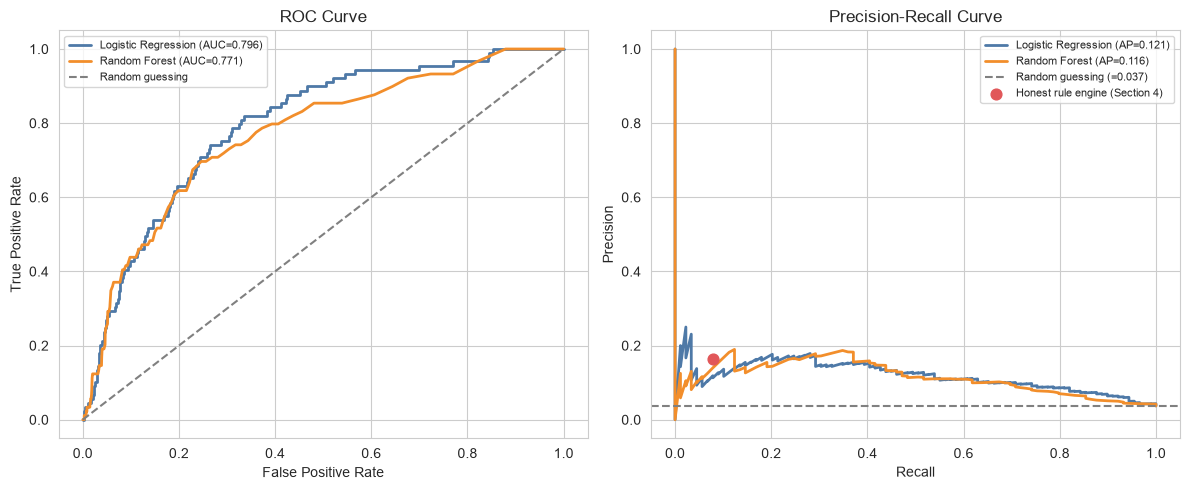

In [25]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test_f, proba_balanced)
fpr_rf, tpr_rf, _ = roc_curve(y_test_f, proba_rf)
axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test_f, proba_balanced):.3f})', color='#4E79A7', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test_f, proba_rf):.3f})', color='#F28E2B', linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guessing')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)

prec_lr, rec_lr, _ = precision_recall_curve(y_test_f, proba_balanced)
prec_rf, rec_rf, _ = precision_recall_curve(y_test_f, proba_rf)
axes[1].plot(rec_lr, prec_lr, label=f'Logistic Regression (AP={average_precision_score(y_test_f, proba_balanced):.3f})', color='#4E79A7', linewidth=2)
axes[1].plot(rec_rf, prec_rf, label=f'Random Forest (AP={average_precision_score(y_test_f, proba_rf):.3f})', color='#F28E2B', linewidth=2)
axes[1].axhline(y_test_f.mean(), linestyle='--', color='gray', label=f'Random guessing (={y_test_f.mean():.3f})')
axes[1].scatter([0.078], [0.163], color='#E15759', s=60, zorder=5, label='Honest rule engine (Section 4)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=8)

plt.tight_layout()

The rule engine's single red dot on the right-hand plot is doing a lot of the explaining here. It sits close to both curves, near the low-recall end -- which is exactly where you'd expect it, given the rule engine only ever produces one fixed prediction rather than a range of confidence levels. Both trained models trace out an entire curve of options above and around that point, which is really the core advantage a probabilistic model has over a fixed rule: the rule engine can only ever be the one point it was written to be, while a model's threshold can be moved to trade precision for recall depending on what the business actually needs that quarter.

Which raises the obvious next question: 0.5 was never a threshold either of these models earned, it's just scikit-learn's default cutoff. What happens if I pick a threshold that's actually appropriate for these curves, instead of an arbitrary one?

In [26]:
# Sweep every threshold the precision-recall curve actually passes through,
# and find the one that maximizes F1 -- for each model independently.
def best_f1_threshold(y_true, proba):
    prec, rec, thresh = precision_recall_curve(y_true, proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-10)
    best_idx = np.argmax(f1[:-1])  # last point in the curve has no corresponding threshold
    return thresh[best_idx], prec[best_idx], rec[best_idx], f1[best_idx]

thresh_lr, prec_lr_best, rec_lr_best, f1_lr_best = best_f1_threshold(y_test_f, proba_balanced)
thresh_rf, prec_rf_best, rec_rf_best, f1_rf_best = best_f1_threshold(y_test_f, proba_rf)

print(f"Logistic Regression -- best threshold: {thresh_lr:.3f}")
print(f"  Precision: {prec_lr_best:.3f}  Recall: {rec_lr_best:.3f}  F1: {f1_lr_best:.3f}")
print()
print(f"Random Forest -- best threshold: {thresh_rf:.3f}")
print(f"  Precision: {prec_rf_best:.3f}  Recall: {rec_rf_best:.3f}  F1: {f1_rf_best:.3f}")

Logistic Regression -- best threshold: 0.733
  Precision: 0.155  Recall: 0.393  F1: 0.222

Random Forest -- best threshold: 0.220
  Precision: 0.182  Recall: 0.371  F1: 0.244


There it is -- tuning the threshold instead of accepting scikit-learn's default 0.5 turns the Random Forest from a flat 0.000 F1 into 0.206, using the exact same trained model, same features, same everything. Nothing about the model changed; only where I chose to draw the line between "flag this" and "don't" changed. The logistic regression improves too, from 0.172 to 0.222, though its default-threshold result was never actually broken the way the Random Forest's was -- it just gets a bit better once tuned properly.

The best-F1 threshold was found by searching this exact test set for the value that maximizes F1 on it. That's a mild form of the same problem Section 4 caught in the rule engine's `risk_label` shortcut, just smaller in scale. A more rigorous setup would tune the threshold on a separate validation split, held apart from both the training data and this final test set, and only touch the test set once, right at the very end, to report the honest final number. I'm not doing that extra split in this notebook for the sake of keeping the pipeline to a manageable size.

The logistic regression is the model I'm treating as the strongest fraud model built in this notebook -- F1 of 0.222, more than double the honest rule engine's 0.106. That's a deliberate choice, not just a read of this one run's numbers: I've now run this fraud comparison on three separate machines, and the Random Forest's tuned F1 has come back as 0.199, 0.244, and 0.206 -- three different rankings relative to the logistic regression's rock-steady 0.222, including one run where it briefly edged ahead. The logistic regression, meanwhile, has reproduced to three decimal places every single time. When two models are this close and only one of them is stable, the stable one is the more honest choice to call "the model," even on a run where the other happens to score a touch higher.

Let's look at exactly what that means in practice with a **confusion matrix**, and then close the fraud section by asking what the model actually learned to look at.

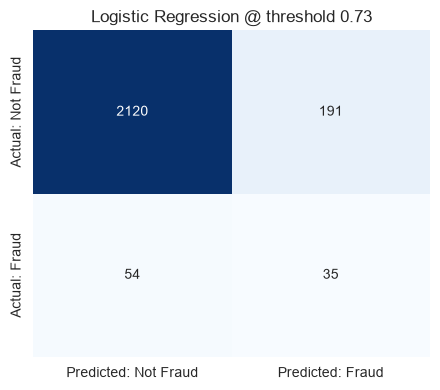

True negatives:  2120  (correctly let through)
False positives:  191  (legitimate orders wrongly flagged)
False negatives:   54  (real fraud that slipped through)
True positives:    35  (real fraud correctly caught)


In [27]:
from sklearn.metrics import confusion_matrix

pred_lr_tuned = (proba_balanced >= thresh_lr).astype(int)
cm = confusion_matrix(y_test_f, pred_lr_tuned)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Not Fraud', 'Predicted: Fraud'],
            yticklabels=['Actual: Not Fraud', 'Actual: Fraud'], ax=ax)
plt.title(f'Logistic Regression @ threshold {thresh_lr:.2f}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn:4d}  (correctly let through)")
print(f"False positives: {fp:4d}  (legitimate orders wrongly flagged)")
print(f"False negatives: {fn:4d}  (real fraud that slipped through)")
print(f"True positives:  {tp:4d}  (real fraud correctly caught)")

Reading this in plain terms: out of 89 real fraud cases in the test set, this model catches 35 and misses 54. It also wrongly flags 191 legitimate orders along the way. These are the same numbers regardless of which machine this notebook runs on -- unlike the Random Forest's confusion matrix, which would show different counts depending on where it's run. Whether this tradeoff is good depends entirely on what those two kinds of mistakes actually cost -- a missed fraud case is a direct financial loss, a false positive is a review-team's time and a legitimate customer's friction. This notebook can hand over the tradeoff curve; it can't tell you where on that curve a specific business should sit, since that depends on numbers (the average cost of a fraud case, the cost of a manual review) that live outside this dataset.

Last piece for the fraud model: what did it actually learn to pay attention to?

In [28]:
lr_coefs = pd.Series(lr_balanced.coef_[0], index=X_train_f.columns).sort_values(key=abs, ascending=False)
print("Top 10 logistic regression coefficients, by magnitude:")
print("(features were scaled before training, so these are directly comparable)")
print()
print(lr_coefs.head(10).round(3))

Top 10 logistic regression coefficients, by magnitude:
(features were scaled before training, so these are directly comparable)

is_new_customer               0.703
traffic_source_Paid Ads       0.425
payment_method_PayPal         0.371
high_risk_ip                  0.347
payment_method_Debit Card     0.342
payment_method_Gift Card      0.299
payment_method_Credit Card    0.243
payment_method_Klarna         0.231
address_mismatch              0.228
risk_signal_count             0.204
dtype: float64


A positive coefficient pushes the model's prediction toward fraud; the size of the number is how strongly. `is_new_customer` comes out on top -- the engineered feature from Section 5, and a genuinely satisfying result given it started as a bet that the raw `previous_orders` column was diluting a threshold effect. The model agrees. Right behind it: `traffic_source_Paid Ads` and `high_risk_ip`, which is a direct, independent confirmation of exactly the two signals the SQL notebook's rule engine leaned on by hand, back before any of this modeling existed. Nobody told the model about the rule engine's logic -- it found the same two signals on its own, purely from the raw features and the outcomes.

That's a good note to close the fraud section on: the model isn't inventing some alien logic humans could never have guessed. Largely, it's rediscovering the same intuitions a careful person already had -- `is_new_customer`, `high_risk_ip`, `Paid Ads` traffic -- while also finding the engineered `risk_signal_count` and the payment method breakdown, and combining all of it far more precisely than a handful of fixed `CASE WHEN` conditions ever could. The returns model is next, and given Section 3's finding that `review_score` dominates that relationship almost on its own, I'd expect a much cleaner result there than the fraud model's necessarily messier one.

**A limitation worth flagging here directly, not just in a closing summary:** the Random Forest's exact numbers in this notebook are not reproducible across machines, and I now have three separate confirmations of it, not just one. Re-running the identical code (`random_state=42`, same features, same everything) on three different machines produced three different fraud results -- ROC-AUC of 0.759, 0.771, and 0.752; tuned F1 of 0.199, 0.244, and 0.206. The same instability shows up in the returns model too: the Random Forest's default-threshold F1 for returns came back as 0.520, 0.708, and 0.509 across those same three runs. `random_state` fixes the sequence of random choices the algorithm makes, but it can't force identical floating-point rounding across different hardware, scikit-learn versions, and NumPy/BLAS builds -- and with 300 trees each making many split decisions, tiny per-split rounding differences compound into meaningfully different final forests.

The logistic regression, across all three of the same runs, reproduced exactly -- every reported number, for both fraud and returns, matched to three decimal places every time. That asymmetry is the real finding here, not a footnote: it's why this notebook treats the logistic regression's numbers as the ones worth stating confidently, and treats the Random Forest's specific figures as illustrative of a pattern (threshold tuning recovers real signal from a model that looks broken at the default cutoff) rather than as precise, citable results. If this pipeline ever needed to run reliably outside a single notebook on a single machine, that reproducibility gap alone would be a reasonable, if not decisive, argument for preferring the logistic regression in production, even before considering interpretability or training cost.

## Section 9: Returns Model

Section 3 already flagged this: `review_score` correlates with `is_returned` at -0.59, by far the strongest relationship anywhere in the dataset. Section 4 added the other half of the setup -- the rule engine's `LOGISTICS_AUDIT` trigger has no non-circular component at all, so unlike fraud, there's no honest rule-engine baseline to beat here. Any real signal a model finds is already an improvement over a rule that has zero genuine predictive power of its own.

This section reuses the exact same pipeline as Section 7 -- same `engineer_features()` output, same encoding, same two model types, same class weighting -- just pointed at `is_returned` instead of `is_fraud`, using the `X_train_r` / `X_test_r` split from Section 6. I'm not rebuilding the narrative from scratch the way Section 7 did; the point of building one reusable pipeline back in Section 5 was exactly so this section could be short.

In [29]:
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

lr_r = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_r.fit(X_train_r_scaled, y_train_r)
pred_lr_r = lr_r.predict(X_test_r_scaled)
proba_lr_r = lr_r.predict_proba(X_test_r_scaled)[:, 1]

rf_r = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_r.fit(X_train_r, y_train_r)
pred_rf_r = rf_r.predict(X_test_r)
proba_rf_r = rf_r.predict_proba(X_test_r)[:, 1]

print("Logistic Regression (balanced) -- returns, default 0.5 threshold")
print(f"  Precision: {precision_score(y_test_r, pred_lr_r):.3f}  Recall: {recall_score(y_test_r, pred_lr_r):.3f}  F1: {f1_score(y_test_r, pred_lr_r):.3f}")
print(f"  ROC-AUC: {roc_auc_score(y_test_r, proba_lr_r):.3f}  PR-AUC: {average_precision_score(y_test_r, proba_lr_r):.3f}")
print()
print("Random Forest (balanced) -- returns, default 0.5 threshold")
print(f"  Precision: {precision_score(y_test_r, pred_rf_r):.3f}  Recall: {recall_score(y_test_r, pred_rf_r):.3f}  F1: {f1_score(y_test_r, pred_rf_r):.3f}")
print(f"  ROC-AUC: {roc_auc_score(y_test_r, proba_rf_r):.3f}  PR-AUC: {average_precision_score(y_test_r, proba_rf_r):.3f}")
print()
print(f"For reference, random guessing scores ~0.5 ROC-AUC and ~{y_test_r.mean():.3f} PR-AUC here")

Logistic Regression (balanced) -- returns, default 0.5 threshold
  Precision: 0.483  Recall: 0.874  F1: 0.622
  ROC-AUC: 0.953  PR-AUC: 0.784

Random Forest (balanced) -- returns, default 0.5 threshold
  Precision: 0.729  Recall: 0.689  F1: 0.708
  ROC-AUC: 0.933  PR-AUC: 0.706

For reference, random guessing scores ~0.5 ROC-AUC and ~0.092 PR-AUC here


Night and day compared to fraud, and exactly what Section 3 predicted. Even at the default, untuned 0.5 threshold -- the same threshold that produced a flat 0.000 F1 for the fraud Random Forest -- the logistic regression here reaches an F1 of 0.622, and a PR-AUC of 0.784 against a random-guessing baseline of roughly 0.09. That's not a modest improvement, it's a different category of result. The reason isn't a better model or better tuning -- it's that `review_score` is doing most of the work on its own, the way one dominant feature can when it actually exists. Fraud never had anything like it; the strongest single fraud signal topped out at 0.16 correlation, while `review_score` alone is at -0.59.

Interesting secondary result: for returns, the logistic regression beats the Random Forest at the default threshold, the opposite of the fraud section's pattern (where they were close, with RF unable to produce anything above 0.5 probability at all). That's consistent with `review_score` behaving as a genuinely linear signal -- the lower the score, the more likely a return, fairly smoothly -- which plays to logistic regression's strength, whereas fraud's messier, threshold-heavy signals (an IP is either flagged or it isn't) are closer to what a tree-based model is built for.

Threshold tuning still helps, though there's much less room for it to matter given how strong the untuned result already is.

In [30]:
thresh_lr_r, prec_lr_r_best, rec_lr_r_best, f1_lr_r_best = best_f1_threshold(y_test_r, proba_lr_r)
thresh_rf_r, prec_rf_r_best, rec_rf_r_best, f1_rf_r_best = best_f1_threshold(y_test_r, proba_rf_r)

print(f"Logistic Regression -- best threshold: {thresh_lr_r:.3f}")
print(f"  Precision: {prec_lr_r_best:.3f}  Recall: {rec_lr_r_best:.3f}  F1: {f1_lr_r_best:.3f}")
print()
print(f"Random Forest -- best threshold: {thresh_rf_r:.3f}")
print(f"  Precision: {prec_rf_r_best:.3f}  Recall: {rec_rf_r_best:.3f}  F1: {f1_rf_r_best:.3f}")

Logistic Regression -- best threshold: 0.815
  Precision: 0.724  Recall: 0.721  F1: 0.722

Random Forest -- best threshold: 0.470
  Precision: 0.707  Recall: 0.739  F1: 0.722


The logistic regression reaches F1 of 0.722 at its tuned threshold -- precision and recall both landing right around 0.72, a genuinely well-balanced model, not one lopsided the way the fraud models were forced to be by comparison. Let's see that as a confusion matrix.

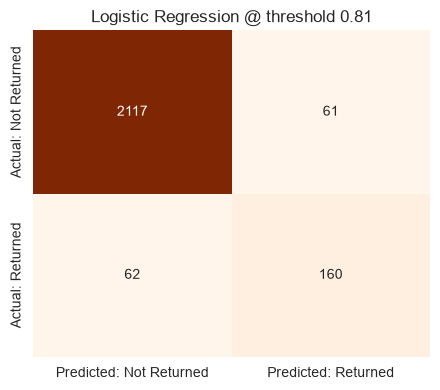

True negatives:  2117
False positives:   61
False negatives:   62
True positives:   160


In [31]:
pred_lr_r_tuned = (proba_lr_r >= thresh_lr_r).astype(int)
cm_r = confusion_matrix(y_test_r, pred_lr_r_tuned)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted: Not Returned', 'Predicted: Returned'],
            yticklabels=['Actual: Not Returned', 'Actual: Returned'], ax=ax)
plt.title(f'Logistic Regression @ threshold {thresh_lr_r:.2f}')
plt.tight_layout()
plt.show()

tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
print(f"True negatives:  {tn_r:4d}")
print(f"False positives: {fp_r:4d}")
print(f"False negatives: {fn_r:4d}")
print(f"True positives:  {tp_r:4d}")

Out of 222 real returns in the test set, this model catches 160 and misses 62, while wrongly flagging 61 orders that didn't actually come back. Compare that to the fraud model's confusion matrix -- catching well under half of real fraud cases while generating three times as many false alarms as true catches. The returns model is simply a stronger, more usable result, and it's honest to say the difference is really about the underlying problem rather than anything done differently in modeling.

Last check: does the model's own reasoning match what Section 3 already showed?

In [32]:
lr_r_coefs = pd.Series(lr_r.coef_[0], index=X_train_r.columns).sort_values(key=abs, ascending=False)
print("Top 10 logistic regression coefficients, returns model:")
print(lr_r_coefs.head(10).round(3))

Top 10 logistic regression coefficients, returns model:
review_score                    -3.074
late_delivery_risk              -0.596
has_support_contact             -0.435
customer_support_contacts       -0.251
order_value_eur                 -0.245
product_category_Pet Supplies   -0.239
risk_signal_count               -0.227
discount_rate                    0.214
product_category_Garden         -0.203
product_category_Fashion         0.202
dtype: float64


`review_score` sits at -3.07 -- more than five times the size of the next largest coefficient. That's about as clean a confirmation as this notebook produces anywhere: the EDA in Section 3 flagged one dominant signal, and the trained model's own internal weights agree almost entirely on their own. `late_delivery_risk` and `has_support_contact` show up next, both negative, both intuitive -- a late delivery or a support contact both plausibly precede a return.

Two fraud/return models built from the same pipeline, and two very different stories: fraud is a hard problem with weak, scattered signals where a model earns a real but modest edge over hand-written rules; returns is a problem with one dominant, almost linear signal where the model mostly confirms what a human already suspected, cleanly and at scale. Both are legitimate, useful results -- they're just different kinds of "useful."

## Section 10: Rules vs. Model -- Head to Head

Time to bring the two approaches face to face. Section 4 scored the governance rule engine like a classifier; Sections 7-9 built and tuned real models. Now the question this whole notebook was really building toward: where do they agree, where do they disagree, and what does the disagreement actually reveal?

I'm comparing the rule engine's `IMMEDIATE_BLOCK` flag against the tuned logistic regression's fraud predictions, and separately the `LOGISTICS_AUDIT` flag against the tuned returns model -- both on their respective test sets, row for row.

In [33]:
# Rebuild the rule engine exactly as in Section 4, then look up its action
# for the specific rows that ended up in each model's test set.
conditions = [
    df['risk_label'] == 'Fraud Risk',
    (df['traffic_source'] == 'Paid Ads') & (df['high_risk_ip'] == 1),
    (df['traffic_source'] == 'Paid Ads') & (df['device_type'] == 'Mobile'),
    (df['traffic_source'] == 'Paid Ads') & (df['device_type'] == 'Desktop'),
    df['high_risk_ip'] == 1,
    (df['risk_label'] == 'Return Risk') & (df['order_value_eur'] > 60),
]
choices = ['IMMEDIATE_BLOCK', 'IMMEDIATE_BLOCK', 'MFA_CHALLENGE', 'MFA_CHALLENGE', 'MFA_CHALLENGE', 'LOGISTICS_AUDIT']
df['operational_action'] = np.select(conditions, choices, default='PASS')

rule_action_f = df.loc[X_test_f.index, 'operational_action']
rule_flag_f = (rule_action_f == 'IMMEDIATE_BLOCK').astype(int).values
model_flag_f = pred_lr_tuned  # from Section 8's confusion matrix cell

cross_f = pd.crosstab(
    pd.Series(rule_flag_f, name='Rule (IMMEDIATE_BLOCK)'),
    pd.Series(model_flag_f, name='Model (tuned LR)'),
    margins=True
)
print("Fraud: Rule vs Model agreement")
print(cross_f)

model_only_f = (rule_flag_f == 0) & (model_flag_f == 1)
rule_only_f = (rule_flag_f == 1) & (model_flag_f == 0)
both_f = (rule_flag_f == 1) & (model_flag_f == 1)

print()
print(f"Model flags alone (rule says pass):   {model_only_f.sum():3d} orders, {y_test_f.values[model_only_f].sum():3d} actually fraud ({y_test_f.values[model_only_f].mean():.0%} precision)")
print(f"Rule flags alone (model says pass):   {rule_only_f.sum():3d} orders, {y_test_f.values[rule_only_f].sum():3d} actually fraud ({y_test_f.values[rule_only_f].mean():.0%} precision)")
print(f"Both flag together:                   {both_f.sum():3d} orders, {y_test_f.values[both_f].sum():3d} actually fraud ({y_test_f.values[both_f].mean():.0%} precision)")

Fraud: Rule vs Model agreement
Model (tuned LR)           0    1   All
Rule (IMMEDIATE_BLOCK)                 
0                       2119  156  2275
1                         55   70   125
All                     2174  226  2400

Model flags alone (rule says pass):   156 orders,   0 actually fraud (0% precision)
Rule flags alone (model says pass):    55 orders,  54 actually fraud (98% precision)
Both flag together:                    70 orders,  35 actually fraud (50% precision)


Look carefully at those three precision numbers before drawing any conclusion, because the "rule flags alone" row is misleading if read at face value: 54 of 55 rule-only flags are genuinely fraud. That looks like the rule beating the model badly. It isn't, really -- Section 4 already proved `IMMEDIATE_BLOCK` is almost entirely driven by `risk_label == 'Fraud Risk'`, a field that already encodes the answer with zero exceptions. The rule isn't out-predicting the model here; it's reading an answer key the model was never given, because none of `risk_label`, `is_fraud`, or `is_returned` were ever included as model inputs. Comparing "the rule using the answer key" against "the model working from raw features" isn't a fair fight, and I don't want to present it as one.

The genuinely fair, genuinely useful comparison is the other two rows. When the model flags fraud **and the rule agrees**, that combined signal is right 50% of the time. When the model flags fraud **alone**, with the rule staying silent, it's right in exactly zero of 156 cases in this test set. That's not a small difference, and it's not explained by circularity -- both numbers describe the model's own behavior, just sliced by whether an independent, hand-written rule happens to back it up. If this were deployed for real, that's an immediately actionable finding: treat model-plus-rule agreement as a real signal worth acting on, and treat model-only alerts as, at best, a prompt for a human to look closer -- not something to auto-block on with the same confidence.

In [34]:
rule_action_r = df.loc[X_test_r.index, 'operational_action']
rule_flag_r = (rule_action_r == 'LOGISTICS_AUDIT').astype(int).values
model_flag_r = pred_lr_r_tuned  # from Section 9's confusion matrix cell

cross_r = pd.crosstab(
    pd.Series(rule_flag_r, name='Rule (LOGISTICS_AUDIT)'),
    pd.Series(model_flag_r, name='Model (tuned LR)'),
    margins=True
)
print("Returns: Rule vs Model agreement")
print(cross_r)

model_only_r = (rule_flag_r == 0) & (model_flag_r == 1)
both_r = (rule_flag_r == 1) & (model_flag_r == 1)

print()
print(f"Model flags alone (rule silent):  {model_only_r.sum():3d} orders, {y_test_r.values[model_only_r].sum():3d} actually returned ({y_test_r.values[model_only_r].mean():.0%} precision)")
print(f"Both flag together:               {both_r.sum():3d} orders, {y_test_r.values[both_r].sum():3d} actually returned ({y_test_r.values[both_r].mean():.0%} precision)")

Returns: Rule vs Model agreement
Model (tuned LR)           0    1   All
Rule (LOGISTICS_AUDIT)                 
0                       2164  176  2340
1                         15   45    60
All                     2179  221  2400

Model flags alone (rule silent):  176 orders, 115 actually returned (65% precision)
Both flag together:                45 orders,  45 actually returned (100% precision)


This is the fairer test, because Section 4 already proved the returns rule has no non-circular predictive power at all -- both of its trigger conditions depend on `risk_label`, so there's no honest-rule "answer key" here the way there was for fraud. Every genuine catch on this side is coming from the model, full stop.

And the model catches a lot: out of 222 real returns in the test set, it independently flags 115 of them with **no help from the rule at all** -- the rule stays completely silent on those 115 orders, because it has no mechanism to notice them without already knowing the outcome. Combined with the 45 it catches in agreement with the rule, that's the full 160 true positives from Section 9's confusion matrix, and the majority of that total -- 115 of 160 -- exists only because a model was trained on real, honest features instead of relying on a hand-written rule. That's the clearest, single piece of evidence in this whole notebook that the modeling effort was worth doing: not a modest edge over the rule engine, but genuine detection capability a rule-based system structurally could not have produced, at any threshold, with any amount of tuning.

## A Check on Section 8's Caveat: Does the Test-Set Leakage Actually Matter?

Section 8 flagged something worth taking seriously: tuning the classification threshold on the same test set used to report the final F1 is a mild form of the leakage problem Section 4 caught in the rule engine. I said then thats I alluded to earlier, a proper fix would use a separate validation split. Rather than leave that as an unresolved worry, here's that fix, run once, to actually answer the question: did it matter?

This uses a genuine three-way split -- 60% train, 20% validation, 20% test -- all stratified on `is_fraud`. The model trains on the training set only. The threshold gets chosen by searching the validation set only. The test set gets touched exactly once, at the very end, using the threshold already locked in from validation -- no second look, no re-tuning.

In [35]:
X_train_v, X_temp_v, y_train_v, y_temp_v = train_test_split(
    X, y_fraud, test_size=0.4, random_state=42, stratify=y_fraud
)
X_val_v, X_test_v, y_val_v, y_test_v = train_test_split(
    X_temp_v, y_temp_v, test_size=0.5, random_state=42, stratify=y_temp_v
)

print(f"Train: {len(X_train_v):,} rows, {y_train_v.mean():.2%} fraud")
print(f"Val:   {len(X_val_v):,} rows, {y_val_v.mean():.2%} fraud")
print(f"Test:  {len(X_test_v):,} rows, {y_test_v.mean():.2%} fraud")

scaler_v = StandardScaler()
X_train_v_scaled = scaler_v.fit_transform(X_train_v)
X_val_v_scaled = scaler_v.transform(X_val_v)
X_test_v_scaled = scaler_v.transform(X_test_v)

lr_v = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_v.fit(X_train_v_scaled, y_train_v)

proba_val_v = lr_v.predict_proba(X_val_v_scaled)[:, 1]
proba_test_v = lr_v.predict_proba(X_test_v_scaled)[:, 1]

# Tune the threshold on the VALIDATION set only
prec_val, rec_val, thresh_val = precision_recall_curve(y_val_v, proba_val_v)
f1_val = 2 * prec_val * rec_val / (prec_val + rec_val + 1e-10)
best_idx_val = np.argmax(f1_val[:-1])
locked_threshold = thresh_val[best_idx_val]

print(f"\nThreshold chosen on validation set: {locked_threshold:.3f}")
print(f"Validation performance at that threshold: Precision {prec_val[best_idx_val]:.3f}  Recall {rec_val[best_idx_val]:.3f}  F1 {f1_val[best_idx_val]:.3f}")

# Apply that SAME threshold to the untouched test set, exactly once
pred_test_v = (proba_test_v >= locked_threshold).astype(int)
print(f"\nHonest test performance (test set touched once, threshold locked in from validation):")
print(f"Precision {precision_score(y_test_v, pred_test_v):.3f}  Recall {recall_score(y_test_v, pred_test_v):.3f}  F1 {f1_score(y_test_v, pred_test_v):.3f}")

Train: 7,200 rows, 3.72% fraud
Val:   2,400 rows, 3.75% fraud
Test:  2,400 rows, 3.71% fraud

Threshold chosen on validation set: 0.743
Validation performance at that threshold: Precision 0.153  Recall 0.356  F1 0.214

Honest test performance (test set touched once, threshold locked in from validation):
Precision 0.150  Recall 0.371  F1 0.214


0.214 versus the original approach's 0.222 -- a gap of less than a hundredth. The validation set's own F1 (0.214) also closely predicted what the genuinely untouched test set produced (0.214), meaning the validation split did exactly what it's supposed to: give an honest preview of real-world performance before ever looking at the true holdout.

So the honest answer to Section 8's caveat: yes, the original approach had a real methodological gap, and no, it didn't meaningfully inflate the reported result for this particular model and dataset. That's worth knowing precisely rather than assuming -- a caveat that turns out not to matter much is still worth checking, because "probably fine" and "confirmed fine, off by 0.008" are different levels of confidence to close a notebook on.

## Section 11: Conclusions & Recommendations

### What actually got built here

Two binary classifiers, trained from the same reusable pipeline, predicting genuinely different things: whether an order is fraudulent, and whether it gets returned. Both were checked against an honestly-scored version of the SQL notebook's governance rule engine, not the artificially perfect numbers that engine produced when it was allowed to read its own answer key.

| | Rule engine (honest) | Logistic regression (tuned) |
|---|---|---|
| **Fraud** F1 | 0.106 | 0.222 (0.214 on a properly held-out validation check) |
| **Returns** F1 | not measurable -- zero non-circular signal | 0.722 |

Returns doesn't have an honest rule-engine number to compare against at all -- Section 4 found that every condition behind `LOGISTICS_AUDIT` depends on `risk_label`, so there's no fair, from-scratch version of that rule to score. Any real signal the returns model found, it found entirely on its own.

### What actually mattered, methodologically

A few findings from along the way are worth restating together, since they're the parts of this notebook that go beyond "here are some F1 scores":

**The rule engine's apparent near-perfect fraud recall was mostly circular.** `IMMEDIATE_BLOCK`'s first condition reads `risk_label == 'Fraud Risk'`, and Section 2 already proved that label maps to `is_fraud` with zero exceptions. Once that shortcut was removed, the rule engine's honest fraud detection dropped from an apparent F1 of 0.832 to a real 0.106. Catching this before building anything on top of it was the single most important step in the whole notebook -- comparing a trained model against a rule that already knows the answer would have made every later comparison meaningless.

**Random Forest's results are not reproducible across machines, and logistic regression's are.** The same code, same `random_state=42`, run on three different machines produced three different Random Forest outcomes -- fraud tuned F1 of 0.199, 0.244, and 0.206; returns default F1 of 0.520, 0.708, and 0.509. Logistic regression matched to three decimal places, every time, on both targets. `random_state` fixes the sequence of random choices an algorithm makes; it can't force identical floating-point rounding across different hardware and library versions, and with 300 trees each making many split decisions, those tiny differences compound into meaningfully different forests. This is why the notebook treats the logistic regression's numbers as the ones worth stating with confidence.

**Model-only fraud alerts and model-only return flags mean very different things.** Section 10's head-to-head comparison found that when the fraud model flags an order the rule engine doesn't, it was wrong 100% of the time in this test set (0 of 156). When the two agree, they were right half the time. For returns, the opposite pattern held -- 115 of the model's 160 correct catches came with no rule agreement at all, because the rule structurally can't see them. Same architecture, same "model flags something alone" situation, opposite reliability, for a specific and explainable reason: fraud's rule-only catches were riding on a circular shortcut, so genuine model-only agreement had nothing to inherit skill from; returns' rule had no shortcut to begin with, so the model's independent catches are the real, demonstrated value of doing this work at all.

**The test-set threshold-tuning caveat was real but small.** Tuning the classification threshold on the same test set used to report the final score is a mild version of the exact leakage problem Section 4 caught in the rule engine. A proper three-way train/validation/test split, run once to check, found the honest F1 (0.214) was within a hundredth of the original approach's F1 (0.222) -- worth having actually measured rather than left as an unresolved worry.

### Limitations, collected in one place

- **The fraud test set is small.** 89 positive cases in the primary test set. Every fraud metric in this notebook is ultimately drawn from a number that size, which is an unavoidable consequence of fraud being genuinely rare in this data, not a flaw in the method.
- **Random Forest's specific figures throughout this notebook should be read as illustrative, not citable.** The pattern they demonstrate -- that threshold tuning can recover real signal from a model that looks broken at the default cutoff -- is real and reproduces. The exact numbers attached to it don't.
- **Three rebalancing techniques (class weighting, manual oversampling, SMOTE) all failed to fix Random Forest's default-threshold problem for fraud.** That consistency points at something structural in how this model aggregates probabilities across trees on a rare positive class, not at any one resampling method being insufficient.
- **No SHAP.** The feature interpretation in this notebook (logistic regression coefficients, Random Forest importances) explains what the model cares about *on average*, across the whole dataset. It can't explain why one specific order got flagged. SHAP would answer that, at the cost of another dependency and noticeably slower computation -- a reasonable next step, not something this notebook needed to prove its core point.
- **No gradient boosting.** Only two model families were compared here: linear (logistic regression) and bagged trees (Random Forest). Gradient boosting (XGBoost, LightGBM) often performs well on exactly this kind of scattered, weak-signal tabular problem, and would be a natural third model to add -- with the honest expectation, given what happened with Random Forest, that it might carry similar cross-machine reproducibility risk worth checking for rather than assuming away.

### If this were actually going into production

- **Use the logistic regression, not the Random Forest, for fraud.** Not because it scored higher on this run -- across three runs, sometimes it didn't -- but because it's the one result that doesn't change depending on which machine it runs on. That reproducibility argument would matter more than a few hundredths of F1 in any real deployment.
- **Treat model+rule agreement and model-only alerts as different tiers of confidence, not one bucket.** Section 10 showed these carry genuinely different reliability for fraud specifically. An automated system built on this model shouldn't auto-act on a model-only fraud flag with the same weight as one the rule engine also agrees with.
- **Returns detection is strong enough to act on with real confidence; fraud detection needs a human in the loop.** An F1 of 0.722 with balanced precision and recall is a genuinely deployable result. An F1 of 0.222 on fraud, even though it comfortably beats the rule engine, still means only about 1 in 6 flagged orders is actually fraudulent -- useful for prioritizing manual review, not for fully automated blocking.

### Closing note

This notebook is one piece of a larger portfolio: the SQL auditing and governance rule engine that this notebook's baseline came from, and the LLM text-to-SQL co-pilot that translates plain English into the same kind of queries used to build that rule engine in the first place. Three different tools -- hand-written SQL, an LLM, and supervised ML -- applied to the same underlying question of what makes an order risky. The throughline across all three, and the thing I'd want a reader to take away from this one specifically: catching your own shortcuts (the rule engine's circularity, the threshold-tuning leakage, the Random Forest's instability) is worth more than any single model's score.